In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv2
import pandas as pd
import os
import glob

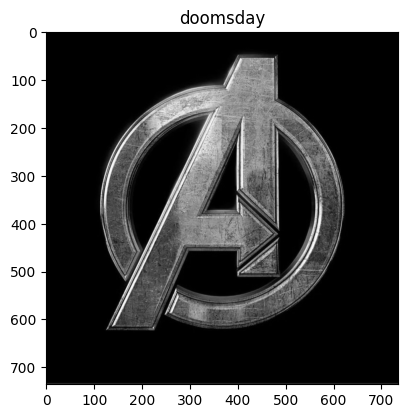

In [2]:
doomsday_bgr = cv2.imread('doomsday.jpg')
doomsday_rgb = cv2.cvtColor(doomsday_bgr, cv2.COLOR_BGR2RGB)
doomsday_gray = cv2.cvtColor(doomsday_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.title("doomsday")
plt.imshow(doomsday_gray, cmap='gray')

In [3]:
def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

In [4]:
# Inisialisasi Filter Low-Pass (LPF) dan High-Pass (HPF)
nilai = 1 / 1.4142135623730950488016887242097
LPF = np.array([nilai, nilai])
HPF = np.array([-nilai, nilai])

# Fungsi Konvolusi Horizontal
def convo_h(image, kernel):
    ukuran_kernel = len(kernel)
    padd = np.pad(image, ((0, 0), (0, ukuran_kernel)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += (padd[i][j+x] * kernel[x])
    return conv

# Fungsi Konvolusi Vertikal
def convo_v(image, kernel):
    ukuran_kernel = len(kernel)
    padd = np.pad(image, ((0, ukuran_kernel), (0, 0)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += (padd[i+x][j] * kernel[x])
    return conv

# Fungsi Downsampling Horizontal
def downsampling_h(image):
    baris = int(image.shape[0])
    kolom = int(image.shape[1] / 2)
    downsampled = np.zeros((baris, kolom))
    for i in range(baris):
        indeks = 0
        for j in range(kolom):
            downsampled[i][j] = image[i][indeks]
            indeks += 2
    return downsampled

# Fungsi Downsampling Vertikal
def downsampling_v(image):
    baris = int(image.shape[0] / 2)
    kolom = int(image.shape[1])
    downsampled = np.zeros((baris, kolom))
    indeks = 0
    for i in range(baris):
        for j in range(kolom):
            downsampled[i][j] = image[indeks][j]
        indeks += 2
    return downsampled

# Fungsi Normalisasi
def normalisasi(image):
    min_val = np.min(image)
    max_val = np.max(image)
    
    if max_val == min_val:
        return np.zeros(image.shape, dtype=np.uint8)
        
    norm = (image - min_val) / (max_val - min_val) * 255.0
    return np.clip(norm, 0, 255).astype(np.uint8)
    # return (image - np.min(image)) / (np.max(image) - np.min(image)) * 255.0

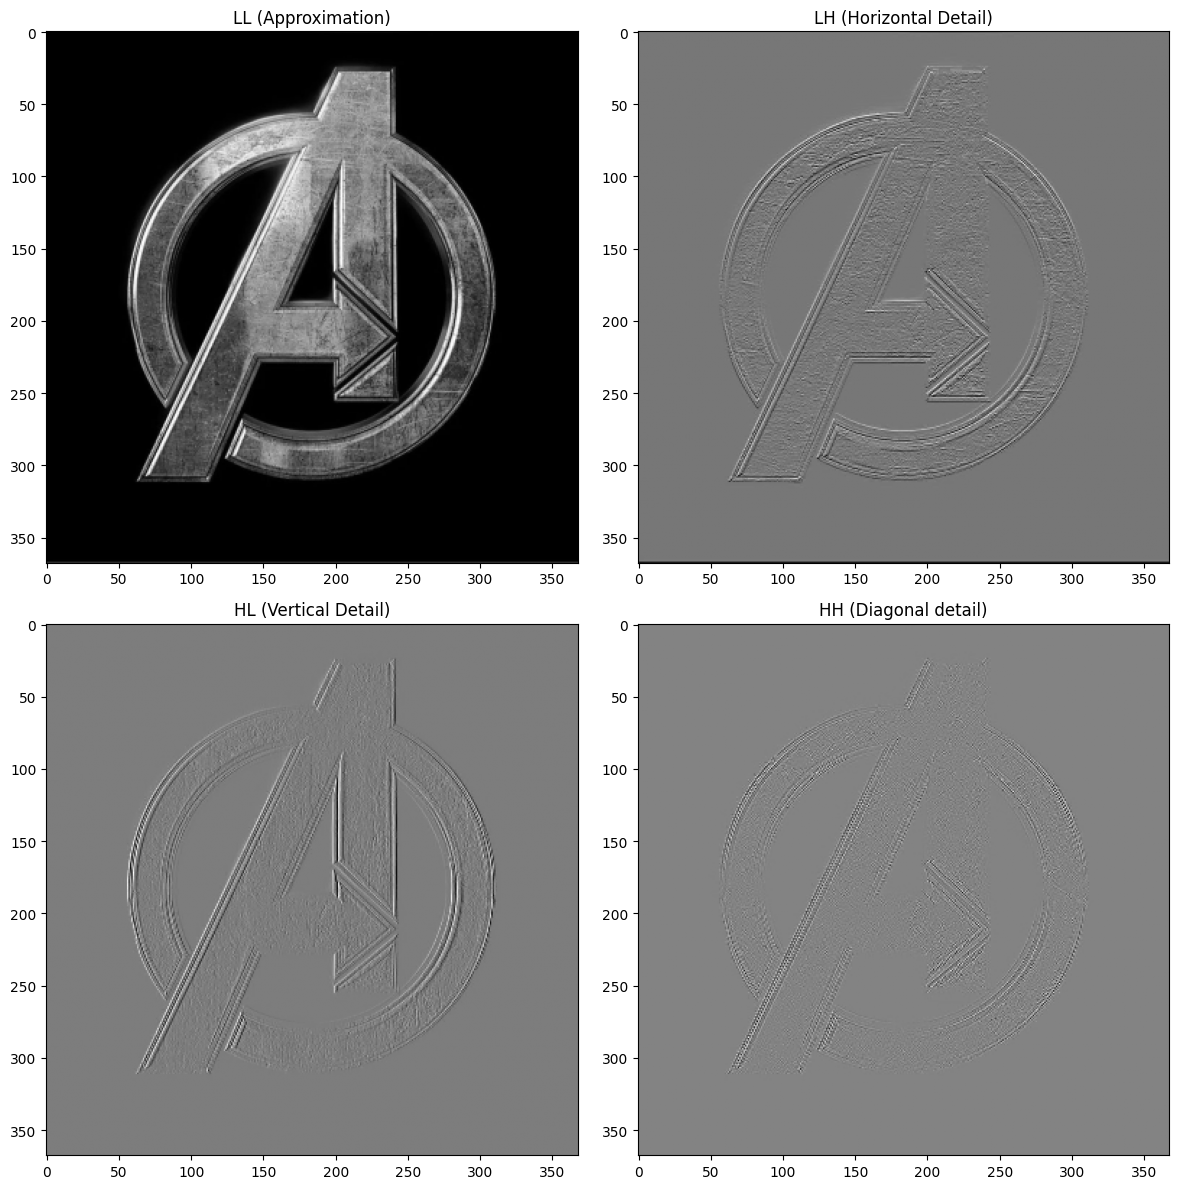

(368, 368)


In [5]:
konvolusi1_LLdoomsday = convo_h(doomsday_gray, LPF)
downsampling1_LLdoomsday = downsampling_h(konvolusi1_LLdoomsday)
konvolusi2_LLdoomsday = convo_v(downsampling1_LLdoomsday, LPF)
approximationdoomsday = downsampling_v(konvolusi2_LLdoomsday)
approximationdoomsday = normalisasi(approximationdoomsday)

konvolusi1_LHdoomsday = convo_h(doomsday_gray, LPF)
downsampling1_LHdoomsday = downsampling_h(konvolusi1_LHdoomsday)
konvolusi2_LHdoomsday = convo_v(downsampling1_LHdoomsday, HPF)
horizontaldoomsday = downsampling_v(konvolusi2_LHdoomsday)
horizontaldoomsday = normalisasi(horizontaldoomsday)

konvolusi1_HLdoomsday = convo_h(doomsday_gray, HPF)
downsampling1_HLdoomsday = downsampling_h(konvolusi1_HLdoomsday)
konvolusi2_HLdoomsday = convo_v(downsampling1_HLdoomsday, LPF)
vertikaldoomsday = downsampling_v(konvolusi2_HLdoomsday)
vertikaldoomsday = normalisasi(vertikaldoomsday)

konvolusi1_HHdoomsday = convo_h(doomsday_gray, HPF)
downsampling1_HHdoomsday = downsampling_h(konvolusi1_HHdoomsday)
konvolusi2_HHdoomsday = convo_v(downsampling1_HHdoomsday, HPF)
diagonaldoomsday = downsampling_v(konvolusi2_HHdoomsday)
diagonaldoomsday = normalisasi(diagonaldoomsday)

plt.figure(figsize=(12, 12))

# Plot LL (Approximation)
plt.subplot(2, 2, 1)
plt.imshow(approximationdoomsday, cmap='gray')
plt.title('LL (Approximation)')

# Plot LH (Horizontal Detail)
plt.subplot(2, 2, 2)
plt.imshow(horizontaldoomsday, cmap='gray')
plt.title('LH (Horizontal Detail)')

# Plot HL (Vertical Detail)
plt.subplot(2, 2, 3)
plt.imshow(vertikaldoomsday, cmap='gray')
plt.title('HL (Vertical Detail)')

# Plot HH (Diagonal detail)
plt.subplot(2, 2, 4)
plt.imshow(diagonaldoomsday, cmap='gray')
plt.title('HH (Diagonal detail)')

plt.tight_layout()
plt.show()
print(approximationdoomsday.shape)

In [6]:
def thresholding(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if(img[i,j] > batas):
                canvas[i,j] = 255
            elif (img[i,j] <= batas):
                canvas[i,j] = 0
    return canvas

Text(0.5, 1.0, 'HH (Diagonal detail)')

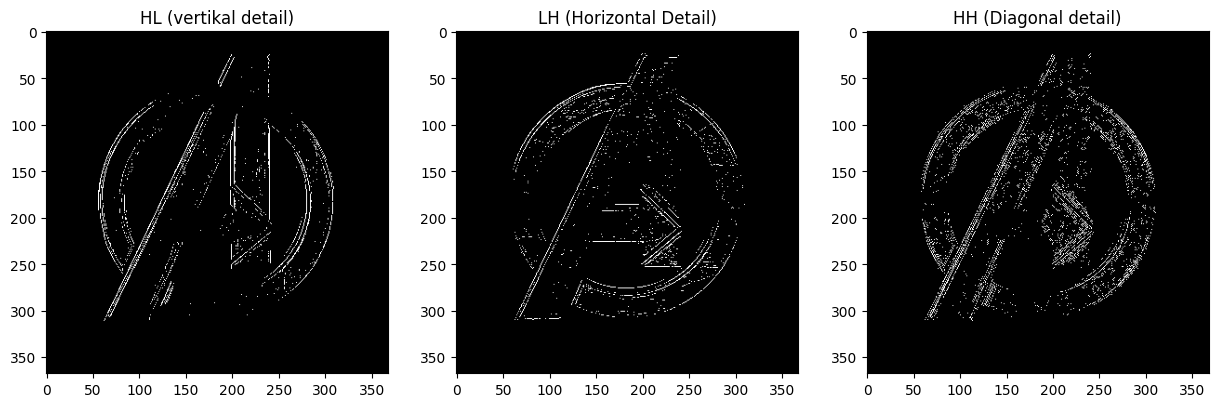

In [7]:
HL_thresholded = thresholding(vertikaldoomsday, 150)
LH_thresholded = thresholding(horizontaldoomsday, 150)
HH_thresholded = thresholding(diagonaldoomsday, 150)

plt.figure(figsize=(15, 15))

plt.subplot(1, 3, 1)
plt.imshow(HL_thresholded, cmap='gray')
plt.title('HL (vertikal detail)')

plt.subplot(1, 3, 2)
plt.imshow(LH_thresholded, cmap='gray')
plt.title('LH (Horizontal Detail)')

plt.subplot(1, 3, 3)
plt.imshow(HH_thresholded, cmap='gray')
plt.title('HH (Diagonal detail)')


In [8]:
kernel5 = np.array([[0, 0, 1, 0, 0],
                    [0, 1, 1, 1, 0],
                    [1, 1, 1, 1, 1],
                    [0, 1, 1, 1, 0],
                    [0, 0, 1, 0, 0]], dtype=np.uint8)

In [9]:
def erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)
    
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            
            if cocok:
                hasil[i, j] = 255
                
    return hasil

def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)
    
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255
    return hasil

def opening(image, kernel):
    # Tahap 1: Lakukan Erosi
    hasil_erosi = erosi(image, kernel)
    # Tahap 2: Lakukan Dilasi pada hasil erosi
    hasil_opening = dilasi(hasil_erosi, kernel)
    return hasil_opening

def closing(image, kernel):
    # Tahap 1: Lakukan Dilasi terlebih dahulu
    hasil_dilasi = dilasi(image, kernel)
    # Tahap 2: Lakukan Erosi pada hasil dilasi
    hasil_closing = erosi(hasil_dilasi, kernel)
    return hasil_closing

Text(0.5, 1.0, 'HH (Diagonal detail)')

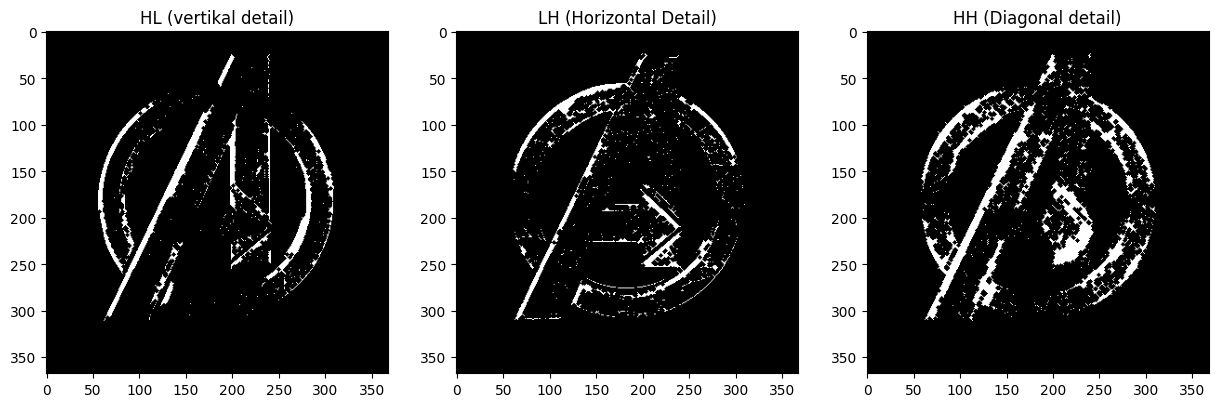

In [10]:
HL_closing = closing(HL_thresholded, kernel5)
LH_closing = closing(LH_thresholded, kernel5)
HH_closing = closing(HH_thresholded, kernel5)

plt.figure(figsize=(15, 15))

plt.subplot(1, 3, 1)
plt.imshow(HL_closing, cmap='gray')
plt.title('HL (vertikal detail)')

plt.subplot(1, 3, 2)
plt.imshow(LH_closing, cmap='gray')
plt.title('LH (Horizontal Detail)')

plt.subplot(1, 3, 3)
plt.imshow(HH_closing, cmap='gray')
plt.title('HH (Diagonal detail)')

### Analisis Karakteristik Hasil Operasi Morfologi Closing

Secara umum, operasi morfologi *closing* (terdiri dari *dilation* yang diikuti oleh *erosion*) berfungsi untuk mengisi celah kecil dan menyambungkan struktur yang terputus pada citra biner, tanpa secara signifikan mengubah ukuran keseluruhan objek. 

Penggunaan kernel 5x5 yang berbentuk **tanda silang (cross)** sangat mempengaruhi bagaimana garis-garis tersebut ditebalkan dan disambungkan, yaitu dengan memperluas piksel putih secara horizontal dan vertikal.

Berikut adalah rincian karakteristik pada masing-masing hasil *subband*:

**1. Karakteristik Umum (Dibandingkan dengan Hasil Thresholding)**
* **Garis Lebih Tegas dan Tebal:** Citra yang sebelumnya tampak tipis dan berupa titik-titik (pada langkah 3) kini berubah menjadi blok-blok garis putih yang solid dan tebal.
* **Celah Tertutup (Hole Filling):** Bagian-bagian garis tepi logo *Avengers* yang tadinya putus-putus berhasil disambungkan. Ini merupakan efek utama dari tahap *dilation* di dalam operasi *closing*.
* **Struktur Logo Lebih Jelas:** Bentuk huruf "A" dan lingkaran di sekelilingnya menjadi jauh lebih mudah dikenali secara visual karena integritas garisnya telah dipulihkan.

**2. Analisis Spesifik per Subband**
* **HL (Garis Vertikal):** Operasi *closing* sangat efektif mempertegas dan menyatukan sisa-sisa deteksi tepi vertikal. Tiang utama huruf "A" pada logo terlihat sangat tebal, menyambung, dan dominan.
* **LH (Garis Horizontal):** Pada citra ini, garis-garis horizontal (seperti palang pada huruf "A" dan panah) serta lengkungan lingkaran berhasil disambungkan dengan baik. Garis-garis yang sebelumnya berupa *noise* halus di sekitar lengkungan kini mengelompok menjadi garis lengkung yang lebih solid.
* **HH (Garis Diagonal / Sudut):** Hasil *thresholding* HH pada langkah 3 merupakan yang paling tersebar dan berupa titik-titik (*noisy*). Setelah dilakukan *closing*, titik-titik diagonal ini saling terhubung membentuk klaster-klaster putih yang tebal, terutama menonjolkan bagian sudut, perpotongan garis, dan detail kasar diagonal dari logo tersebut.

**Kesimpulan**
Penggunaan operasi *closing* dengan kernel *cross* berukuran 5x5 sangat berhasil memperbaiki garis-garis tepi yang terfragmentasi akibat nilai *threshold* yang cukup tinggi (150) pada langkah sebelumnya. Operasi ini mengembalikan struktur dasar logo sehingga garisnya tidak lagi putus-putus.

In [11]:
def convolve_rows(image, kernel):
    """Konvolusi 1D sepanjang baris."""
    kernel = np.asarray(kernel).ravel()
    k = len(kernel)
    pad = k // 2

    padded = np.pad(image, ((0, 0), (pad, pad)), mode='edge')
    out = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            out[i, j] = np.sum(padded[i, j:j+k] * kernel)

    return out

def convolve_cols(image, kernel):
    """Konvolusi 1D sepanjang kolom."""
    kernel = np.asarray(kernel).ravel()
    k = len(kernel)
    pad = k // 2

    padded = np.pad(image, ((pad, pad), (0, 0)), mode='edge')
    out = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            out[i, j] = np.sum(padded[i:i+k, j] * kernel)

    return out

def upsample_rows(image):
    """Upsample 2x hanya baris."""
    h, w = image.shape
    up = np.zeros((h * 2, w), dtype=np.float32)
    up[::2, :] = image
    return up


def upsample_cols(image):
    """Upsample 2x hanya kolom."""
    h, w = image.shape
    up = np.zeros((h, w * 2), dtype=np.float32)
    up[:, ::2] = image
    return up


def upRowConvolve(comp, filt_row):
    """Upsample baris lalu konvolusi arah baris."""
    up = upsample_rows(comp)
    return convolve_rows(up, filt_row)


def upColConvolve(comp, filt_col):
    """Upsample kolom lalu konvolusi arah kolom."""
    up = upsample_cols(comp)
    return convolve_cols(up, filt_col)


def rekonstruksi(LL, LH, HL, HH, low_filter=LPF, high_filter=HPF):
    # inverse tahap kolom
    low_part = (
        convolve_cols(upsample_rows(LL), low_filter) +
        convolve_cols(upsample_rows(LH), high_filter)
    )
    high_part = (
        convolve_cols(upsample_rows(HL), low_filter) +
        convolve_cols(upsample_rows(HH), high_filter)
    )

    # inverse tahap baris
    hasil = (
        convolve_rows(upsample_cols(low_part), low_filter) +
        convolve_rows(upsample_cols(high_part), high_filter)
    )

    return hasil

Text(0.5, 1.0, '')

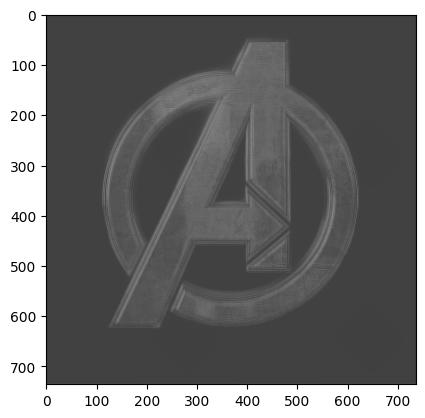

In [12]:
# nomor 5a

doomsday_rekonstruksi = rekonstruksi(approximationdoomsday, horizontaldoomsday, vertikaldoomsday, diagonaldoomsday)

plt.imshow(doomsday_rekonstruksi, cmap='gray')
plt.axis("on")
plt.title("")


### Analisis Hasil Rekonstruksi Citra (Inverse DWT)

**a. Rekonstruksi LL, HL, LH, HH (Asli)**
* **Analisis:** Menggabungkan kembali semua komponen (Aproksimasi dan Detail) secara utuh akan mengembalikan citra persis ke bentuk dan intensitas aslinya. Hal ini membuktikan sifat *lossless* (tanpa kehilangan informasi) dari Transformasi Wavelet jika tidak ada modifikasi atau kompresi pada koefisien-koefisiennya.

Text(0.5, 1.0, '')

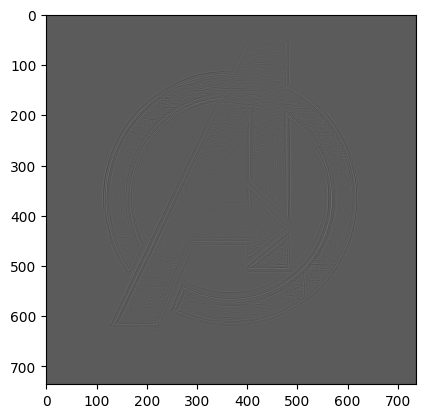

In [13]:
# nomor 5b
LL_nol = np.zeros_like(approximationdoomsday, dtype=np.float32)
doomsday_rekonstruksiLL0 = rekonstruksi(LL_nol, horizontaldoomsday, vertikaldoomsday, diagonaldoomsday)

plt.imshow(doomsday_rekonstruksiLL0, cmap='gray')
plt.axis("on")
plt.title("")


**b. Rekonstruksi dengan Mengganti LL = 0 (Detail Asli Level 1)**
* **Analisis:** Subband LL (Low-Pass Filter) mengandung informasi frekuensi rendah, yaitu warna dasar, pencahayaan, dan latar belakang citra. Dengan mengubah semua elemen LL menjadi 0, kita membuang informasi dasar tersebut. Akibatnya, hasil rekonstruksi hanya menampilkan **tepi, tekstur, dan garis kontur** dari citra (informasi frekuensi tinggi) dengan latar belakang gelap. Gambar akan terlihat seperti hasil operasi deteksi tepi (*edge detection*).

Text(0.5, 1.0, '')

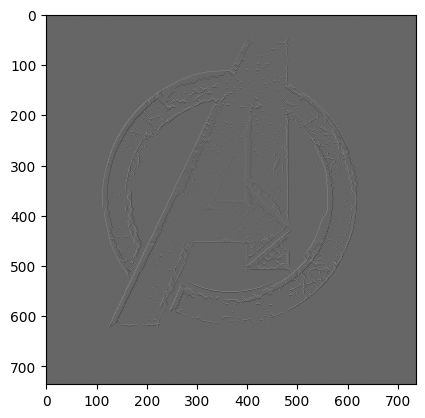

In [14]:
# nomor 5b
doomsday_rekonstruksiLL0_closing = rekonstruksi(LL_nol, LH_closing, HL_closing, HH_closing)

plt.imshow(doomsday_rekonstruksiLL0_closing, cmap='gray')
plt.axis("on")
plt.title("")


**c. Rekonstruksi dengan LL = 0 dan Detail Hasil Closing**
* **Analisis:** Pada tahap ini, selain kehilangan warna dasar, koefisien detail yang dikembalikan telah mengalami manipulasi ekstrem (*thresholding* biner dan penebalan *closing*). Hasil rekonstruksinya akan menampilkan garis tepi yang sangat **tebal, kaku, dan artifisial**. Karena basis wavelet Haar berbentuk persegi panjang (fungsi tangga), proses *inverse* dari garis-garis biner yang tebal ini akan menghasilkan efek *blocking* atau pikselasi yang berbentuk kotak-kotak di sepanjang garis tepi logo.

In [15]:
def upsample_rows2(image):
    h, w = image.shape
    up = np.zeros((h*2, w), dtype=np.float32)
    up[::2, :]  = image
    up[1::2, :] = image
    return up

def upsample_cols2(image):
    h, w = image.shape
    up = np.zeros((h, w*2), dtype=np.float32)
    up[:, ::2]  = image
    up[:, 1::2] = image
    return up

def convolve_rows2(image, kernel):
    """Konvolusi 1D sepanjang baris."""
    kernel = np.asarray(kernel).ravel()
    k = len(kernel)
    pad = k // 2
    padded = np.pad(image, ((0, 0), (pad, pad)), mode='edge')
    out = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            out[i, j] = np.sum(padded[i, j:j+k] * kernel)
    return out

def convolve_cols2(image, kernel):
    """Konvolusi 1D sepanjang kolom."""
    kernel = np.asarray(kernel).ravel()
    k = len(kernel)
    pad = k // 2
    padded = np.pad(image, ((pad, pad), (0, 0)), mode='edge')
    out = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            out[i, j] = np.sum(padded[i:i+k, j] * kernel)
    return out

def rekonstruksi2(LL, LH, HL, HH, low_filter=LPF, high_filter=HPF):
    low_part  = (convolve_cols2(upsample_rows2(LL), low_filter)  + convolve_cols2(upsample_rows2(LH), high_filter))
    high_part = (convolve_cols2(upsample_rows2(HL), low_filter)  + convolve_cols2(upsample_rows2(HH), high_filter))
    hasil = (convolve_rows2(upsample_cols2(low_part),  low_filter) + convolve_rows2(upsample_cols2(high_part), high_filter))
    return hasil

Text(0.5, 1.0, '')

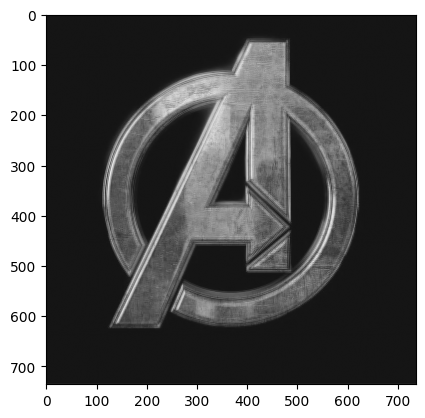

In [16]:
# nomor 5d
doomsday_rekonstruksiAsli = rekonstruksi2(approximationdoomsday, horizontaldoomsday, vertikaldoomsday, diagonaldoomsday)

plt.imshow(doomsday_rekonstruksiAsli, cmap='gray')
plt.axis("on")
plt.title("")